<h1 style="font-size: 1.6rem; font-weight: bold">ITO5201 Machine Learning</h1>
<h1 style="font-size: 1.6rem; font-weight: bold">Document Clustering</h1>
<p style="margin-top: 5px; margin-bottom: 5px;">Monash University Australia</p>
<p style="margin-top: 5px; margin-bottom: 5px;">Jupyter Notebook by: Tristan Sim Yook Min</p>
References: Information Source from Monash Faculty of Information Technology

---

### **Document Clustering**

In Lecture 8 we discussed the Document Clustering problem where we have a collection of n documents, which we try to group into K different clusters. We explored using Expectation Maximisation to solve this problem, which you may have to implement as part of Assignment 2. However, we also mentioned that the problem can also be solved using K-Means Clustering, which will be the focus of this activity. 

### **KMeans Clustering**

While we will not be implementing a KMeans clustering algorithm in this lab, it is worth understanding what objective the algorithm is trying to achieve during its' fitting process. 

The K-Means Clustering algorithm tries to separate the data into K clusters, such that each datapoint has minimal distance to the mean of the cluster it belongs to. For higher dimensional data, $\mu$ is the centroid of the points in the cluster. 

\begin{equation}
\argmin_S \sum_{i=1}^k \sum_{x\in S_i} ||x - \mu_i||^2 = \argmin_S \sum_{i=1}^k |S_i| Var(S_i)
\end{equation}

Finding the optimal solution to the problem is NP-hard, so most approaches to solving this problem involve using heuristics to find approximate solutions instead. 

***

### **Task A: Aquiring Data**

We use a subset of a publicly available dataset called 20 Newsgroups originally published in http://qwone.com/~jason/20Newsgroups/. This dataset contains more than 18K documents covering 20 different topics. For the simplicity and reducing the execution and evaluation times, we only use ~2700 samples randomly selected from 4 categories. The filtered data is stored in `20ng-train-all-terms.txt` file.

Read in the text file '20ng-train-all-terms.txt' and split the file up into individual documents and their associated label. Note that each line of the file contains a label followed by an article separated by \t. Then, store the data in a Pandas DataFrame for ease of visualisation. Note that we will continue to use Numpy arrays for all computational processes as this is faster and more efficient than Pandas. We can cast a Pandas DataFrame to a numpy array with the .values method. 

In [2]:
import pandas as pd 
import numpy as np

with open('20ng-train-all-terms.txt', 'r') as file:
    text = file.readlines()
all([length == 2 for length in [len(line.split('\t')) for line in text]])
labels, articles = [line.split('\t')[0].strip() for line in text], [line.split('\t')[1].strip() for line in text]
docs = pd.DataFrame(data = zip(labels,articles), columns=['label', 'article'])
docs.label = docs.label.astype('category')
docs.head()

,label,article
0,sci.crypt,ripem frequently asked questions archive name ...
1,sci.crypt,ripem frequently asked questions archive name ...
2,sci.crypt,ripem frequently noted vulnerabilities archive...
3,sci.crypt,certifying authority question answered if you ...
4,sci.crypt,rubber hose cryptanalysis some sick part of me...


### **Task B: Feature Extraction**

At the moment each of our documents are being stored as a single, very long string. This makes doing any analysis very inconventient. Instead of using our raw data directly, we will instead perform feature extraction on the data before doing our clustering. 

The features should be numerical, otherwise our Euclidean distance (non-similarity) measure will not work. 

To do so, we use `sklearn.feature_extraction.text.CountVectorizer` to tailor the texts and calculate word counts (frequency of each word in each single document) as the features.

Use the CountVectorizer to exctract features from the data. The min_df parameter controls the minimum number of times a word needs to be featured in the text before it is added to the feature space. Find a value for this feature that you feel is appropriate and justify your choice. 

In [3]:
from sklearn.feature_extraction.text import CountVectorizer

min_freq = 10
feature_options = []
for i in range(min_freq):
    ### YOUR CODE HERE ###
    cv = CountVectorizer(min_df=i+1)   # only keep words appearing in at least i+1 documents

    ### END YOUR CODE HERE ###
    features = cv.fit_transform(raw_documents=articles)
    feature_options += [features]
    print(len(cv.get_feature_names_out()))

# features = feature_options[] # Which option should we choose?
# features.shape

30594
17108
12449
10013
8380
7267
6461
5837
5335
4864


### **Task C: Document Clustering with Kmeans**

Implement an sklearn pipeline which takes as input raw text data, performs feature extraction using CountVectorizer and then fits the data using KMeans. Use the min_freq value you selected in Task B and assume we know the real number of clusters (4 newsgroups). Use this pipeline to fit the raw articles data. 

In [4]:
from sklearn.cluster import KMeans
from sklearn.pipeline import make_pipeline
### YOUR CODE HERE ###
cv = CountVectorizer(min_df=2)      # filter out very rare words (adjust based on previous experiment)
km = KMeans(n_clusters=5, random_state=0, n_init=10)   # choose K based on your data/task
pipe = make_pipeline(cv, km)
### END YOUR CODE HERE ###
pipe.fit

pipe.fit(articles)

,steps,"[('countvectorizer', ...), ('kmeans', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


### **Task D: Principal Component Analysis and Visualization**
Recal that our feature space is a high-dimensional one and we cannot plot all the dimensions. 

Principal Component Analysis is an algorithm that transforms our data into a new coordinate system. This new coordinate system is constructed such that features are ordered in decending order of how much of the variance in the data they explain. 

PCA is often commonly used technique for dimensionality reduction, as we can often discard all but a few of the most highly ranked features and still maintain much of the data's explanatory power. 

Use sklearn.decomposition.PCA to perform a PCA, extracting only first two principle components (components with the largest eigenvalues), then use these components to plot a lower dimensional represenation of our data. 

**Note:** The color codes can be very different in these plots as the cluster orders, and hence their labels and colors, can be very different.

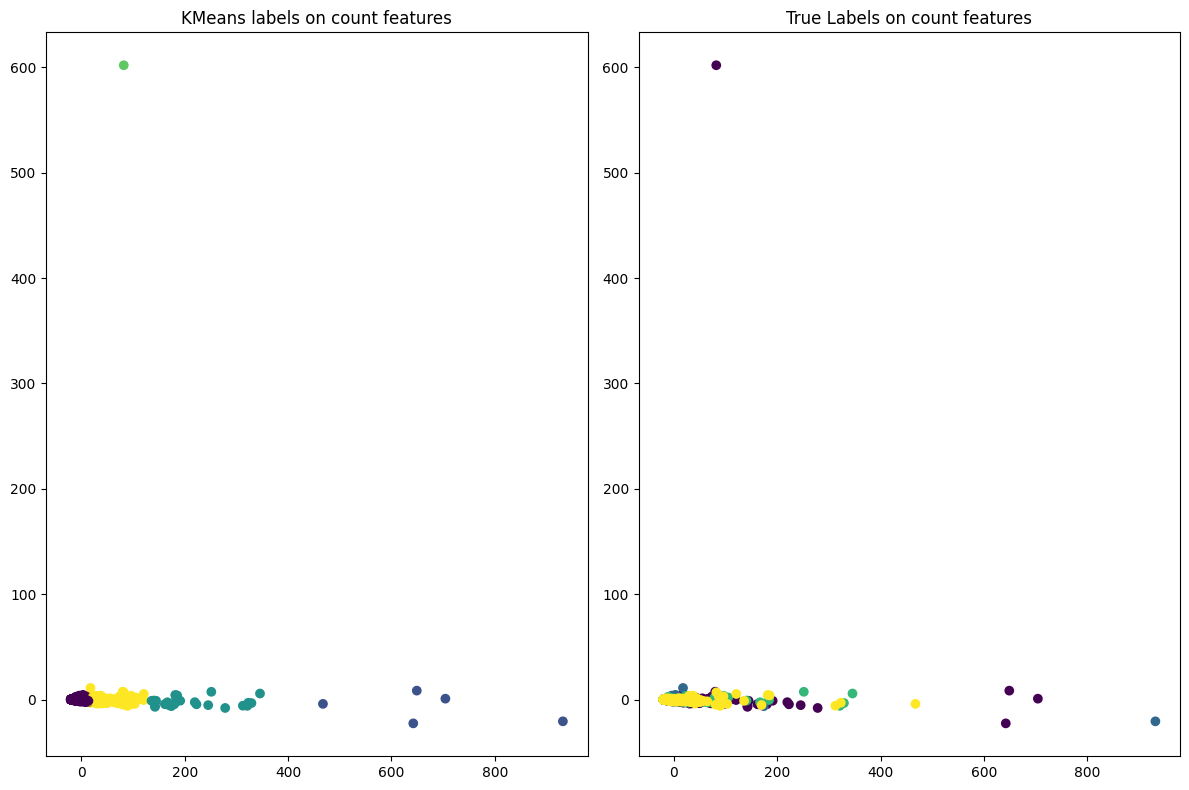

In [5]:
## perform pca
from sklearn.decomposition import PCA
from matplotlib import pyplot as plt

### YOUR CODE HERE ###
pca = PCA(n_components=2, random_state=0)
_2D_features = pca.fit_transform(cv.transform(articles).toarray())
### END YOUR CODE HERE ###

## plot the kmeans outcome
_, axs = plt.subplots(1, 2, figsize=(12, 8), tight_layout=True)
axs[0].scatter(x=_2D_features[:,0],y=_2D_features[:,1], c=km.labels_)
axs[0].set_title('KMeans labels on count features')


## plot the original data
axs[1].scatter(x=_2D_features[:,0],y=_2D_features[:,1], c=docs.label.cat.codes)
axs[1].set_title('True Labels on count features')
plt.show()

### **Task E: A Simple Normalization**
As the above figures, in some cases the data samples are located far from each other, while in some other cases, they are colocated. Also note that the scale of PCs can be very different. This suggests that with a normalization we might get better result as the performance of Kmeans is very sensitive to the distance between the points.

Use sklearn.preprocessing.Normalizer to normalise the data using the l2 norm and then refit KMeans on the newly normalised data. 
This can all be incorporated into a single pipeline that perorms feature extraction using CountVectorizer, then normalises the data using Normalizer then fits using KMeans. 

Finally, perform a 2 component PCA again, plot the results and compare them to the ones in the above plot. Has the fit improved? 

In [6]:
# normalise by dividing each feature row by its L2 norm
from sklearn.preprocessing import Normalizer
### YOUR CODE HERE ###
l2_norm = Normalizer(norm='l2')
features_normalised = l2_norm.fit_transform(features)
### END YOUR CODE HERE ###

features_normalised.shape

(2373, 4864)

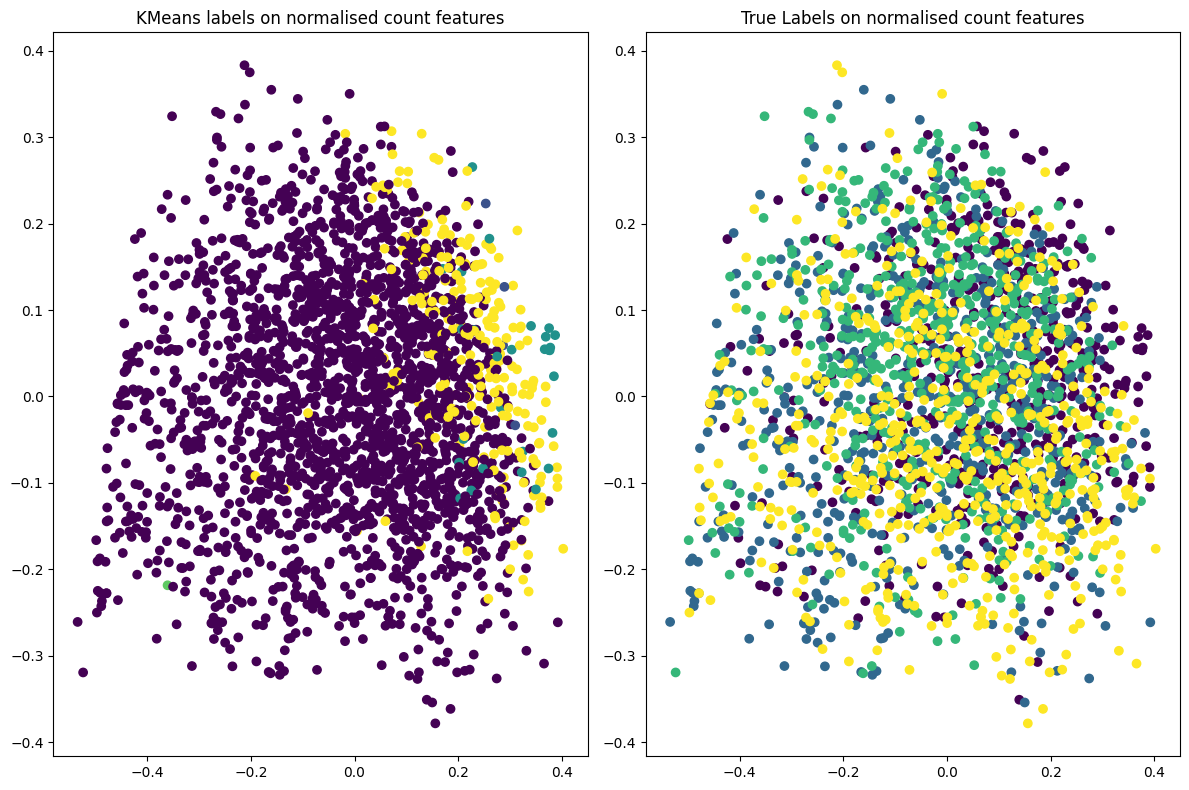

In [7]:
## perform pca
### YOUR CODE HERE ###
pca = PCA(n_components=2, random_state=0)
_2D_features = pca.fit_transform(features_normalised.toarray())
### END YOUR CODE HERE ###

## plot the kmeans outcome
_, axs = plt.subplots(1, 2, figsize=(12, 8), tight_layout=True)
axs[0].scatter(x=_2D_features[:,0],y=_2D_features[:,1], c=km.labels_)
axs[0].set_title('KMeans labels on normalised count features')


## plot the original data
axs[1].scatter(x=_2D_features[:,0],y=_2D_features[:,1], c=docs.label.cat.codes)
axs[1].set_title('True Labels on normalised count features')
plt.show()

### **Task F: A More Advanced Set of Features**

The simple normalization improved Kmeans outcome, but not that much. This suggests that not only the initialization and number of clusters have great impact on the kmeans outcome, but the feature space itself should be discriminative as well. In the followings, we try another feature (instead of the simple word counts) that is knonw as Term Frequency-Inverse Document Frequency (TFIDF). In its core, TFIDF in nothing but weighted word count.

Let's calculate TFIDF feature values and then repeat the above experimetns. Implement another pipeline that performs feature extraction using TFIDF and then fits using KMeans. Note that we do not need to explictly include a normaliser in the pipeline as TfidfVectorizer can perform the normalisation itself if we set the norm argument. 

Perform another 2 component PCA again, plot the results and compare them to the ones in the above plot. Has the fit improved? 

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
### YOUR CODE HERE ###
tfidf = TfidfVectorizer(min_df=2)          # same min_df threshold as before, for consistency
km = KMeans(n_clusters=5, random_state=0, n_init=10)
pipe = make_pipeline(tfidf, km)
### END YOUR CODE HERE ###
pipe.fit(articles)

,steps,"[('tfidfvectorizer', ...), ('kmeans', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


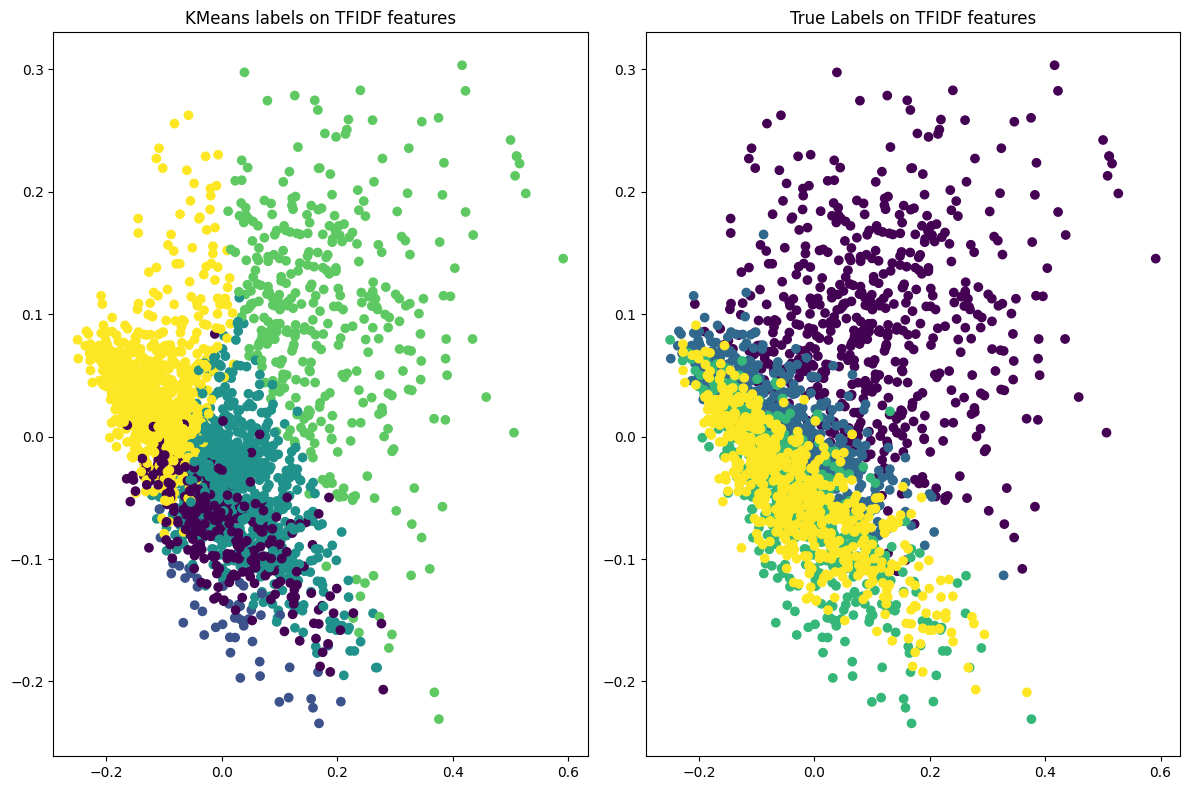

In [9]:
## perform pca
### YOUR CODE HERE ###
pca = PCA(n_components=2, random_state=0)
_2D_features = pca.fit_transform(tfidf.transform(articles).toarray())
### END YOUR CODE HERE ###

## plot the kmeans outcome
_, axs = plt.subplots(1, 2, figsize=(12, 8), tight_layout=True)
axs[0].scatter(x=_2D_features[:,0],y=_2D_features[:,1], c=km.labels_)
axs[0].set_title('KMeans labels on TFIDF features')


## plot the original data
axs[1].scatter(x=_2D_features[:,0],y=_2D_features[:,1], c=docs.label.cat.codes)
axs[1].set_title('True Labels on TFIDF features')
plt.show()

### **Task G: Model Evaluation**

To evaluate the alignment between our cluster predictions and the ground truth labels, we use a clustering evaluation metric such as normalised mutual information index. Note that we can not use a metric like `accuracy` because there is no guarantee that our cluster ids are aligned with our class label ids so instead we use a measure of mutual information such as NMI. (See [this source](https://towardsdatascience.com/7-evaluation-metrics-for-clustering-algorithms-bdc537ff54d2#ebd4) for more information).

Based on the NMI scores below, do you have a feel for which feature creation method is better for this dataset? How confident do you feel about this statement? What could you do to make yourself more certain?

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import normalized_mutual_info_score as NMI

In [11]:
docs_train, docs_test = train_test_split(docs, test_size=0.2, random_state=123)
X_train, y_train = docs_train.article.values, docs_train.label.cat.codes
X_test, y_test = docs_test.article.values, docs_test.label.cat.codes

In [12]:
cv = CountVectorizer(lowercase=True,
                     stop_words='english',
                     min_df=5, )

tfidf = TfidfVectorizer(lowercase=True,
                     stop_words='english',
                     min_df=5,
                    norm='l2')

l2_norm = Normalizer(norm='l2')

km = KMeans(n_clusters=4)

In [13]:
pipe_cv = make_pipeline(cv, l2_norm, km)
pipe_cv.fit(X_train)

NMI(pipe_cv.predict(X_train), y_train), NMI(pipe_cv.predict(X_test), y_test)

(0.3276039298770069, 0.3041392227507338)

In [ ]:
pipe_tfidf = make_pipeline(tfidf, km)
pipe_tfidf.fit(X_train)

NMI(pipe_tfidf.predict(X_train), y_train), NMI(pipe_tfidf.predict(X_test), y_test)

### **Task H: Learning Curve**

Let us examine our conclusion from Task G by repeating the experiment many times, across many different dataset sizes. 

Complete the code in the cell below to generate the results necessary to plot a learning curve over the train size, comparing CountVectorizer and TfidfVectorizer as a method for creating features from our raw data. 

We will only perform 10 repetitions on 10 train sizes as this will already take around 5 minutes to run on most laptops.

After this, compute the mean and the size of the 1.96 standard error bar from res_array and use this to plot an errorbar comparing our two methods. Do these results align with what we saw in Task G? How confident are you in these results? 

In [17]:
from Activity4 import BootstrapSplitter
from sklearn.metrics import normalized_mutual_info_score

import warnings
warnings.filterwarnings('ignore')

train_sizes = np.logspace(start=0.8, stop=0.99, num=10, base=len(articles))/len(articles)
reps = 10

cv = CountVectorizer(lowercase=True,
                     stop_words='english',
                     min_df=5, )

tfidf = TfidfVectorizer(lowercase=True,
                     stop_words='english',
                     min_df=5,
                    norm='l2')

l2_norm = Normalizer(norm='l2')

km = KMeans(n_clusters=4)

res_array = np.zeros(shape=(4, len(train_sizes), reps))
for i, train_size in enumerate(train_sizes):
    print('N_{0}={1}: rep='.format(i, int(train_size*len(articles))), end='')
    splitter = BootstrapSplitter(reps=reps, train_size=train_size, random_state=0)
    for j, (train_idx, test_idx) in enumerate(splitter.split(articles)):
        print('{0}'.format(j), end=', ')
        ### YOUR CODE HERE ###
        train_articles = [articles[idx] for idx in train_idx]
        test_articles = [articles[idx] for idx in test_idx]
        train_labels = docs.label.cat.codes.values[train_idx]
        test_labels = docs.label.cat.codes.values[test_idx]

        # --- CountVectorizer pipeline ---
        cv_train_feats = cv.fit_transform(train_articles)
        cv_test_feats = cv.transform(test_articles)

        km.fit(cv_train_feats)
        cv_train_pred = km.labels_
        cv_test_pred = km.predict(cv_test_feats)

        res_array[0, i, j] = normalized_mutual_info_score(train_labels, cv_train_pred)
        res_array[1, i, j] = normalized_mutual_info_score(test_labels, cv_test_pred)

        # --- TF-IDF pipeline ---
        tfidf_train_feats = tfidf.fit_transform(train_articles)
        tfidf_test_feats = tfidf.transform(test_articles)

        km.fit(tfidf_train_feats)
        tfidf_train_pred = km.labels_
        tfidf_test_pred = km.predict(tfidf_test_feats)

        res_array[2, i, j] = normalized_mutual_info_score(train_labels, tfidf_train_pred)
        res_array[3, i, j] = normalized_mutual_info_score(test_labels, tfidf_test_pred)
        ### END YOUR CODE HERE ###
    print()

N_0=501: rep=0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 
N_1=590: rep=0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 
N_2=696: rep=0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 
N_3=820: rep=0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 
N_4=966: rep=0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 
N_5=1138: rep=0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 
N_6=1342: rep=0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 
N_7=1581: rep=0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 
N_8=1863: rep=0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 
N_9=2195: rep=0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 


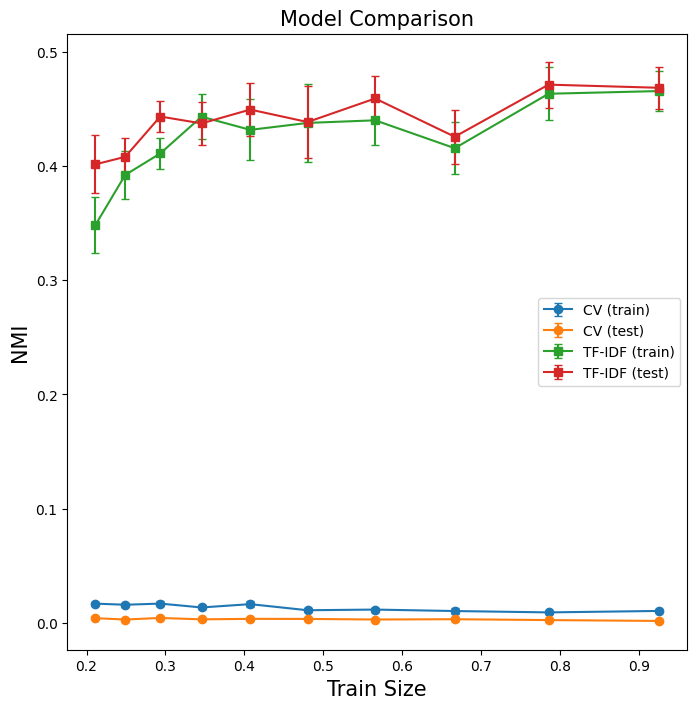

In [18]:
fig, axs = plt.subplots(1, 1)
fig.set_figheight(8)
fig.set_figwidth(8)

### YOUR CODE HERE ###
# res_array shape: (4, n_train_sizes, reps)
# index 0 = CV train, 1 = CV test, 2 = TF-IDF train, 3 = TF-IDF test

mus = res_array.mean(axis=2)                          # shape (4, n_train_sizes)
stes = res_array.std(axis=2) / np.sqrt(res_array.shape[2])  # standard error, same shape

axs.errorbar(train_sizes, mus[0], yerr=stes[0],
             label='CV (train)', marker='o', capsize=3)
axs.errorbar(train_sizes, mus[1], yerr=stes[1],
             label='CV (test)', marker='o', capsize=3)
axs.errorbar(train_sizes, mus[2], yerr=stes[2],
             label='TF-IDF (train)', marker='s', capsize=3)
axs.errorbar(train_sizes, mus[3], yerr=stes[3],
             label='TF-IDF (test)', marker='s', capsize=3)
### END YOUR CODE HERE ###

axs.set_xlabel('Train Size', size=15)
axs.set_ylabel('NMI', size=15)
axs.set_title('Model Comparison', size=15)
axs.legend()

***

### **Discussions:**

**1. Other main limitation of KMeans (beyond initialization and choice of K):**

- KMeans relies on Euclidean distance to a single centroid, which implicitly assumes clusters are spherical, equally sized, and equally dense
- It has no notion of cluster shape, orientation, or variance — every cluster is treated as an isotropic blob regardless of how the actual data is distributed
- For high-dimensional sparse features (like bag-of-words/TF-IDF vectors), Euclidean distance becomes less meaningful: in high dimensions, distances between points tend to concentrate and become less discriminative (the "curse of dimensionality"), and Euclidean distance doesn't account for the fact that document similarity is often better captured by direction/angle (cosine similarity) rather than magnitude
- This is part of why normalization (L2 / TF-IDF) helped earlier — it reduces (but doesn't fully solve) the mismatch between Euclidean distance and the actual geometry of text data
- Bottom line: KMeans' fixed distance metric and lack of per-cluster shape modeling is a structural limitation, separate from the initialization/K-selection issues already discussed

**2. Remedy, using EM techniques from the previous chapter:**

- Replace KMeans with a full GMM fit via EM, since GMM